## 0. Imports & Setup

In [2]:
import json
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image
from pyquaternion import Quaternion

# Root paths
DATA_ROOT = Path("../data/raw/v1.0-mini")
ANNO_ROOT = DATA_ROOT / "v1.0-mini"
SAMPLES_ROOT = DATA_ROOT / "samples"

print("Data root exists:", DATA_ROOT.exists())
print("Annotation files:", [f.name for f in ANNO_ROOT.iterdir()])
print("Camera channels:", [d.name for d in SAMPLES_ROOT.iterdir() if d.is_dir() and 'CAM' in d.name])

Data root exists: True
Annotation files: ['sensor.json', 'attribute.json', 'instance.json', 'log.json', 'calibrated_sensor.json', 'scene.json', 'sample_data.json', 'category.json', 'sample.json', 'visibility.json', 'sample_annotation.json', 'ego_pose.json', 'map.json']
Camera channels: ['CAM_FRONT_LEFT', 'CAM_FRONT_RIGHT', 'CAM_FRONT', 'CAM_BACK', 'CAM_BACK_LEFT', 'CAM_BACK_RIGHT']


## 1. Load nuScenes via Official Devkit

The nuScenes devkit gives us a clean API over the raw JSON files. Under the hood it's just loading the JSON tables we'll also inspect manually below.

In [3]:
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(version='v1.0-mini', dataroot=str(DATA_ROOT), verbose=True)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.124 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


## 2. Understand the Data Schema

nuScenes is organized as a hierarchy of JSON tables:

```
scene  →  sample  →  sample_data  (raw sensor files)
                  →  sample_annotation  (3D boxes per object instance)
                       →  instance  →  category
```

Each record is linked by `token` (UUID string).

In [4]:
# ── Raw table sizes ──────────────────────────────────────────────
tables = ['scene', 'sample', 'sample_data', 'sample_annotation',
          'instance', 'category', 'sensor', 'calibrated_sensor', 'ego_pose']

print(f"{'Table':<25} {'# Records':>10}")
print("-" * 37)
for t in tables:
    records = getattr(nusc, t)
    print(f"{t:<25} {len(records):>10}")

Table                      # Records
-------------------------------------
scene                             10
sample                           404
sample_data                    31206
sample_annotation              18538
instance                         911
category                          23
sensor                            12
calibrated_sensor                120
ego_pose                       31206


In [5]:
# ── Inspect one scene ────────────────────────────────────────────
scene = nusc.scene[0]
print("Scene fields:", list(scene.keys()))
print()
for k, v in scene.items():
    print(f"  {k}: {v}")

Scene fields: ['token', 'log_token', 'nbr_samples', 'first_sample_token', 'last_sample_token', 'name', 'description']

  token: cc8c0bf57f984915a77078b10eb33198
  log_token: 7e25a2c8ea1f41c5b0da1e69ecfa71a2
  nbr_samples: 39
  first_sample_token: ca9a282c9e77460f8360f564131a8af5
  last_sample_token: ed5fc18c31904f96a8f0dbb99ff069c0
  name: scene-0061
  description: Parked truck, construction, intersection, turn left, following a van


In [6]:
# ── Walk scene -> samples ────────────────────────────────────────
print("All 10 scenes:")
print(f"  {'Name':<15} {'# Samples':>10}  Description")
print("  " + "-" * 70)
for s in nusc.scene:
    print(f"  {s['name']:<15} {s['nbr_samples']:>10}  {s['description'][:60]}")

All 10 scenes:
  Name             # Samples  Description
  ----------------------------------------------------------------------
  scene-0061              39  Parked truck, construction, intersection, turn left, followi
  scene-0103              40  Many peds right, wait for turning car, long bike rack left, 
  scene-0553              41  Wait at intersection, bicycle, large truck, peds crossing cr
  scene-0655              41  Parking lot, parked cars, jaywalker, bendy bus, gardening ve
  scene-0757              41  Arrive at busy intersection, bus, wait at intersection, bicy
  scene-0796              40  Scooter, peds on sidewalk, bus, cars, truck, fake constructi
  scene-0916              41  Parking lot, bicycle rack, parked bicycles, bus, many peds, 
  scene-1077              41  Night, big street, bus stop, high speed, construction vehicl
  scene-1094              40  Night, after rain, many peds, PMD, ped with bag, jaywalker, 
  scene-1100              40  Night, peds in sidewa

In [7]:
# ── Inspect one sample ───────────────────────────────────────────
sample_token = nusc.scene[0]['first_sample_token']
sample = nusc.get('sample', sample_token)
print("Sample fields:", list(sample.keys()))
print()
print("Sensor keys in this sample:")
for key in sample['data']:
    print(f"  {key}")

Sample fields: ['token', 'timestamp', 'prev', 'next', 'scene_token', 'data', 'anns']

Sensor keys in this sample:
  RADAR_FRONT
  RADAR_FRONT_LEFT
  RADAR_FRONT_RIGHT
  RADAR_BACK_LEFT
  RADAR_BACK_RIGHT
  LIDAR_TOP
  CAM_FRONT
  CAM_FRONT_RIGHT
  CAM_BACK_RIGHT
  CAM_BACK
  CAM_BACK_LEFT
  CAM_FRONT_LEFT


In [8]:
# ── Inspect one annotation ───────────────────────────────────────
ann_token = sample['anns'][0]
ann = nusc.get('sample_annotation', ann_token)
print("Annotation fields:")
for k, v in ann.items():
    print(f"  {k}: {v}")

Annotation fields:
  token: ef63a697930c4b20a6b9791f423351da
  sample_token: ca9a282c9e77460f8360f564131a8af5
  instance_token: 6dd2cbf4c24b4caeb625035869bca7b5
  visibility_token: 1
  attribute_tokens: ['4d8821270b4a47e3a8a300cbec48188e']
  translation: [373.256, 1130.419, 0.8]
  size: [0.621, 0.669, 1.642]
  rotation: [0.9831098797903927, 0.0, 0.0, -0.18301629506281616]
  prev: 
  next: 7987617983634b119e383d8a29607fd7
  num_lidar_pts: 1
  num_radar_pts: 0
  category_name: human.pedestrian.adult


## 3. Category Distribution

Understanding class imbalance is critical before training — this directly informs loss weighting in Phase 2.

In [9]:
from collections import Counter

# Count annotations per category across the entire mini split
category_counts = Counter()
for ann in nusc.sample_annotation:
    category_counts[ann['category_name']] += 1

# Sort descending
sorted_cats = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)

print(f"{'Category':<45} {'Count':>6}")
print("-" * 53)
for cat, count in sorted_cats:
    print(f"{cat:<45} {count:>6}")

Category                                       Count
-----------------------------------------------------
vehicle.car                                     7619
human.pedestrian.adult                          4765
movable_object.barrier                          2323
movable_object.trafficcone                      1378
vehicle.truck                                    649
vehicle.motorcycle                               471
vehicle.bus.rigid                                353
vehicle.bicycle                                  243
vehicle.construction                             196
human.pedestrian.construction_worker             193
movable_object.pushable_pullable                  82
vehicle.trailer                                   60
vehicle.bus.bendy                                 57
static_object.bicycle_rack                        54
human.pedestrian.child                            46
human.pedestrian.personal_mobility                25
movable_object.debris                        

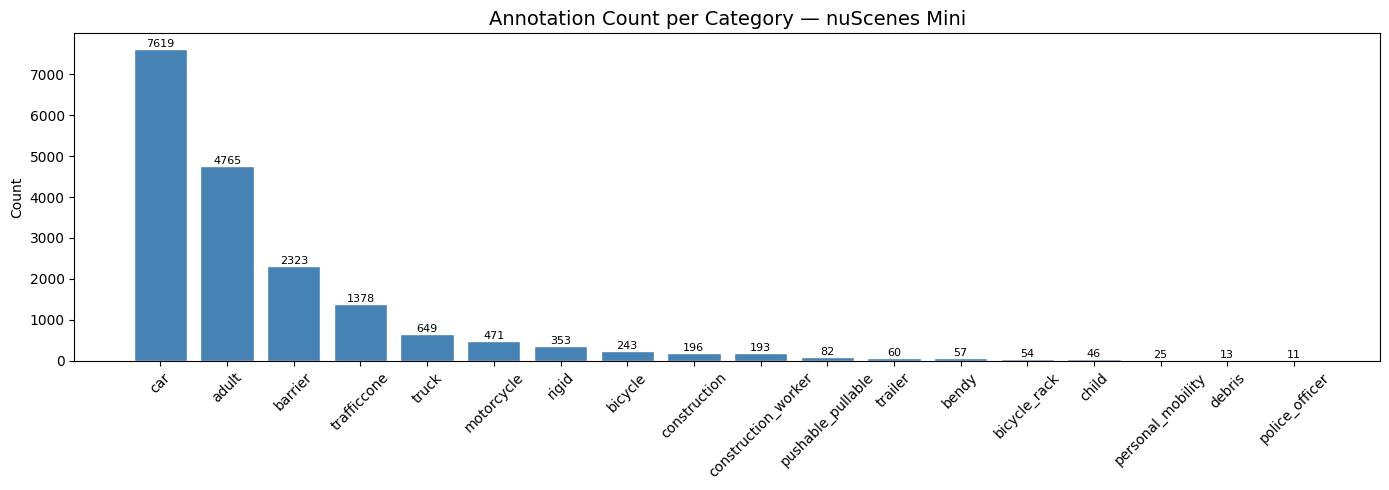


Total annotations: 18538
Total samples: 404
Avg annotations per sample: 45.9


In [10]:
# ── Bar chart ────────────────────────────────────────────────────
cats, counts = zip(*sorted_cats)
short_names = [c.split('.')[-1] if '.' in c else c for c in cats]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(short_names, counts, color='steelblue', edgecolor='white')
ax.set_title('Annotation Count per Category — nuScenes Mini', fontsize=14)
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nTotal annotations: {sum(counts)}")
print(f"Total samples: {len(nusc.sample)}")
print(f"Avg annotations per sample: {sum(counts)/len(nusc.sample):.1f}")

## 4. Visualize All 6 Cameras for One Sample

Each timestep has a synchronized ring of 6 cameras covering 360°.

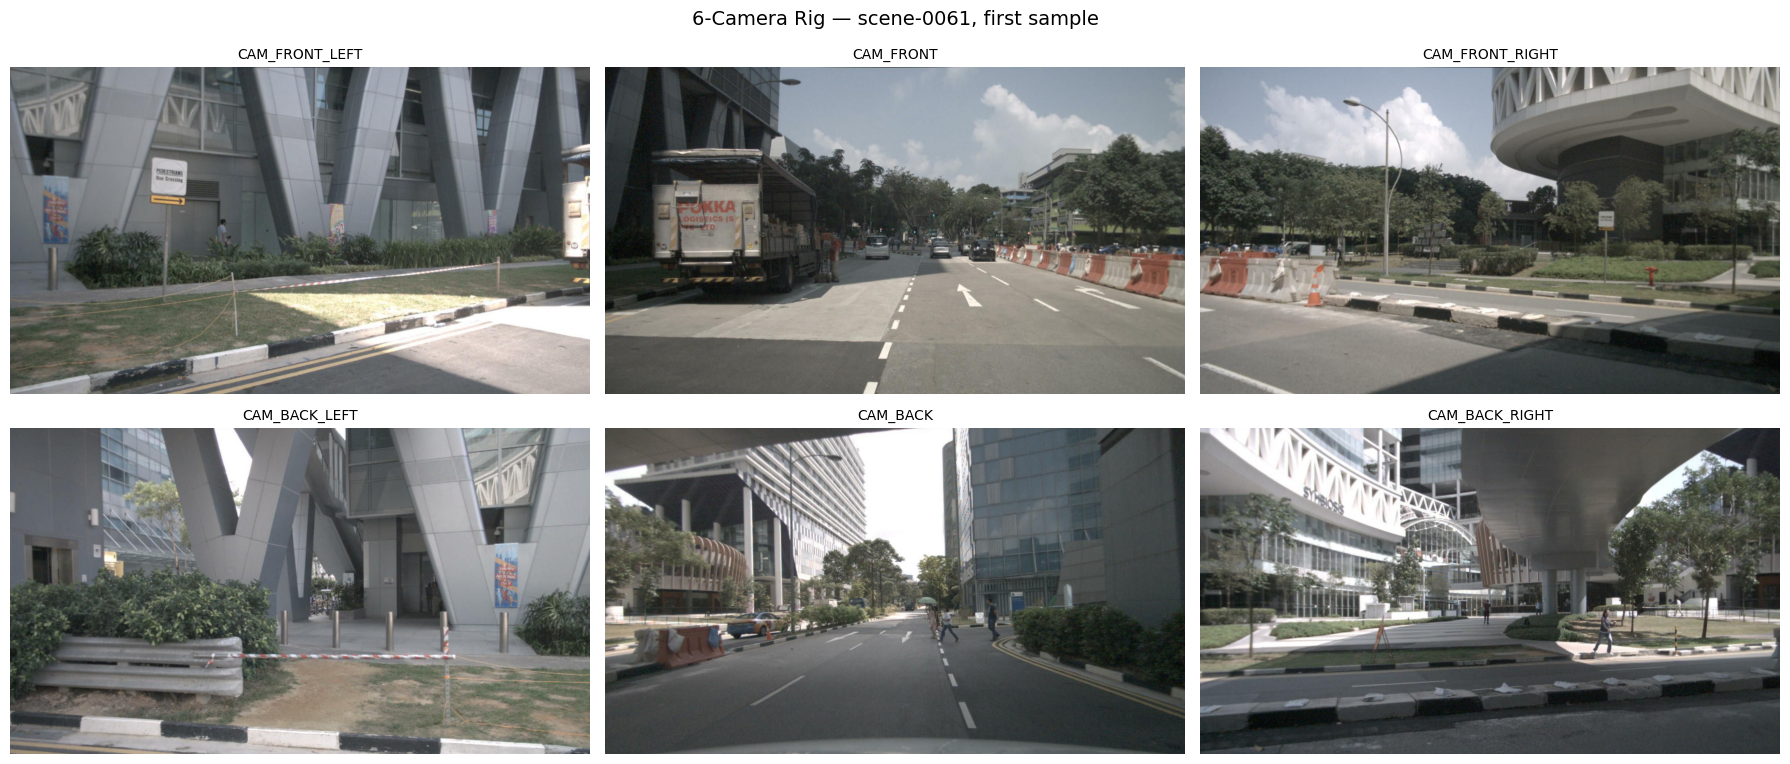

In [11]:
CAMERAS = ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
           'CAM_BACK_LEFT',  'CAM_BACK',  'CAM_BACK_RIGHT']

sample = nusc.get('sample', nusc.scene[0]['first_sample_token'])

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle(f"6-Camera Rig — {nusc.scene[0]['name']}, first sample", fontsize=14)

for ax, cam in zip(axes.flat, CAMERAS):
    sd = nusc.get('sample_data', sample['data'][cam])
    img_path = DATA_ROOT / sd['filename']
    img = np.array(Image.open(img_path))
    ax.imshow(img)
    ax.set_title(cam, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. 2D Bounding Box Annotations on Front Camera

nuScenes stores 3D boxes. We project them into 2D using the devkit helper, then draw them manually so you can see the math.

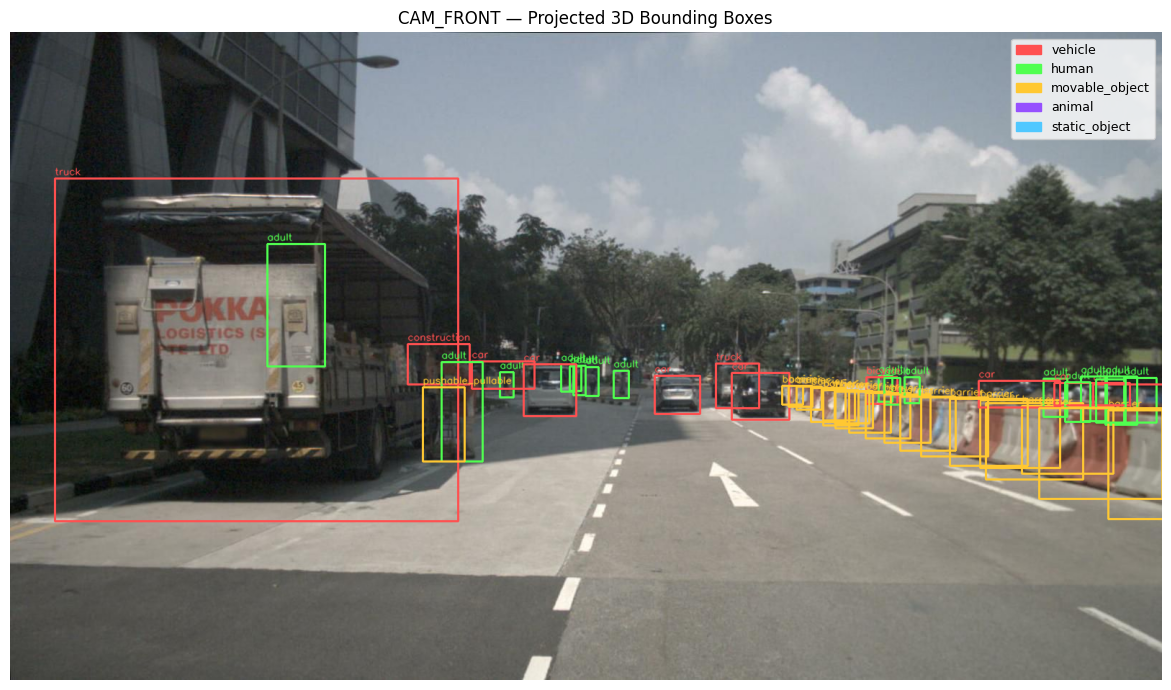

In [12]:
from nuscenes.utils.geometry_utils import view_points, box_in_image, BoxVisibility
from nuscenes.utils.data_classes import Box

# ── Color map per top-level category ────────────────────────────
CATEGORY_COLORS = {
    'vehicle':    (255,  80,  80),
    'human':      ( 80, 255,  80),
    'movable_object': (255, 200,  50),
    'animal':     (150,  80, 255),
    'static_object': (80, 200, 255),
}

def get_color(category_name):
    top = category_name.split('.')[0]
    return CATEGORY_COLORS.get(top, (200, 200, 200))


def render_boxes_on_image(nusc, sample, camera='CAM_FRONT'):
    """Draw 3D→2D projected boxes onto a camera image."""
    sd_token  = sample['data'][camera]
    sd        = nusc.get('sample_data', sd_token)
    cs        = nusc.get('calibrated_sensor', sd['calibrated_sensor_token'])
    ego_pose  = nusc.get('ego_pose', sd['ego_pose_token'])

    img_path  = DATA_ROOT / sd['filename']
    img       = np.array(Image.open(img_path)).copy()

    K = np.array(cs['camera_intrinsic'])  # 3×3

    _, boxes, _ = nusc.get_sample_data(sd_token, box_vis_level=BoxVisibility.ANY)

    for box in boxes:
        color = get_color(box.name)

        # Project 3D corners -> 2D
        corners = view_points(box.corners(), K, normalize=True)  # 3×8
        xs = corners[0].astype(int)
        ys = corners[1].astype(int)

        # Draw 2D bounding rect from projected corners
        x1, y1 = xs.min(), ys.min()
        x2, y2 = xs.max(), ys.max()
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, box.name.split('.')[-1], (x1, max(y1-5, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)

    return img


# Render front camera
sample = nusc.get('sample', nusc.scene[0]['first_sample_token'])
img = render_boxes_on_image(nusc, sample, 'CAM_FRONT')

plt.figure(figsize=(14, 7))
plt.imshow(img)
plt.title('CAM_FRONT — Projected 3D Bounding Boxes')
plt.axis('off')

# Legend
patches = [mpatches.Patch(color=[c/255 for c in v], label=k)
           for k, v in CATEGORY_COLORS.items()]
plt.legend(handles=patches, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

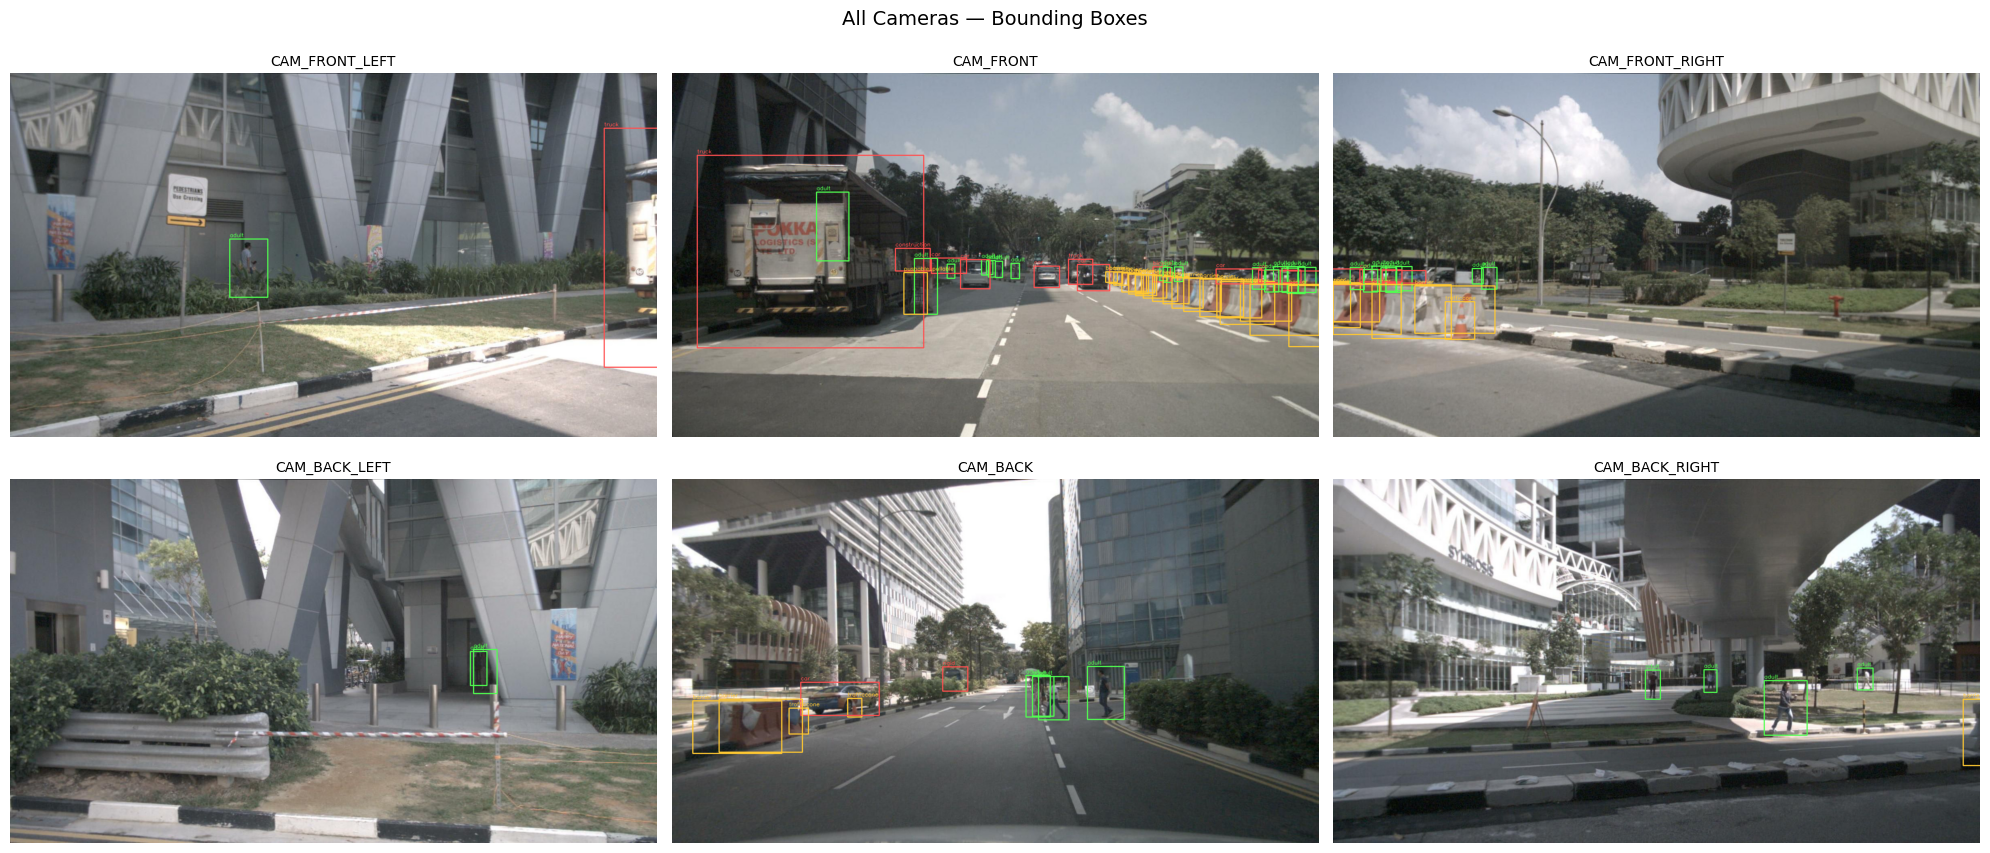

In [13]:
# ── All 6 cameras with boxes side by side ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 9))
fig.suptitle('All Cameras — Bounding Boxes', fontsize=14)

for ax, cam in zip(axes.flat, CAMERAS):
    img = render_boxes_on_image(nusc, sample, cam)
    ax.imshow(img)
    ax.set_title(cam, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6. Camera Intrinsic & Extrinsic Parameters

**Critical for Phase 5 (BEV Transform).** These are the matrices that define how 3D world points map onto each camera's 2D image plane.

- **Intrinsic K** — focal length, principal point. Encodes the camera's internal optics.
- **Extrinsic (R, t)** — rotation + translation from the *ego vehicle frame* to the *camera frame*.

In [14]:
print("=" * 70)
print("CAMERA INTRINSIC & EXTRINSIC PARAMETERS")
print("=" * 70)

for cam in CAMERAS:
    sd_token = sample['data'][cam]
    sd = nusc.get('sample_data', sd_token)
    cs = nusc.get('calibrated_sensor', sd['calibrated_sensor_token'])

    K = np.array(cs['camera_intrinsic'])
    t = np.array(cs['translation'])            # ego -> camera (meters)
    q = Quaternion(cs['rotation'])             # ego -> camera (quaternion)
    R = q.rotation_matrix                      # 3×3

    print(f"\n{'─'*60}")
    print(f"  {cam}")
    print(f"{'─'*60}")
    print(f"  Intrinsic K (3×3):")
    print(f"    fx={K[0,0]:.2f}  fy={K[1,1]:.2f}")
    print(f"    cx={K[0,2]:.2f}  cy={K[1,2]:.2f}")
    np.set_printoptions(precision=3, suppress=True)
    print(f"    Full K:\n{K}")
    print(f"  Extrinsic translation (ego→cam): {t}")
    print(f"  Extrinsic rotation (R):\n{R}")

CAMERA INTRINSIC & EXTRINSIC PARAMETERS

────────────────────────────────────────────────────────────
  CAM_FRONT_LEFT
────────────────────────────────────────────────────────────
  Intrinsic K (3×3):
    fx=1272.60  fy=1272.60
    cx=826.62  cy=479.75
    Full K:
[[1272.598    0.     826.615]
 [   0.    1272.598  479.752]
 [   0.       0.       1.   ]]
  Extrinsic translation (ego→cam): [1.524 0.495 1.509]
  Extrinsic rotation (R):
[[ 0.821 -0.     0.571]
 [-0.571  0.003  0.821]
 [-0.002 -1.     0.002]]

────────────────────────────────────────────────────────────
  CAM_FRONT
────────────────────────────────────────────────────────────
  Intrinsic K (3×3):
    fx=1266.42  fy=1266.42
    cx=816.27  cy=491.51
    Full K:
[[1266.417    0.     816.267]
 [   0.    1266.417  491.507]
 [   0.       0.       1.   ]]
  Extrinsic translation (ego→cam): [1.701 0.016 1.511]
  Extrinsic rotation (R):
[[ 0.006 -0.006  1.   ]
 [-1.    -0.001  0.006]
 [ 0.001 -1.    -0.006]]

────────────────────────

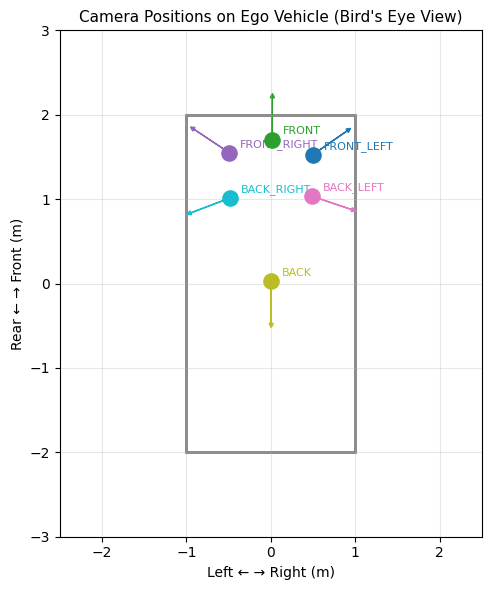

In [15]:
# ── Visualize camera positions in bird's eye view ────────────────
# This gives an intuition for where each camera sits on the car.

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title("Camera Positions on Ego Vehicle (Bird's Eye View)", fontsize=11)

# Draw a simple car rectangle
car = plt.Rectangle((-1, -2), 2, 4, fill=False, edgecolor='gray', linewidth=2, label='Ego vehicle')
ax.add_patch(car)

colors_cam = plt.cm.tab10(np.linspace(0, 1, 6))

for i, cam in enumerate(CAMERAS):
    sd_token = sample['data'][cam]
    sd = nusc.get('sample_data', sd_token)
    cs = nusc.get('calibrated_sensor', sd['calibrated_sensor_token'])
    t = np.array(cs['translation'])
    q = Quaternion(cs['rotation'])

    # Camera position (x=right, y=forward in ego frame)
    ax.scatter(t[1], t[0], s=120, color=colors_cam[i], zorder=5)
    ax.annotate(cam.replace('CAM_', ''), (t[1], t[0]),
                textcoords='offset points', xytext=(8, 4), fontsize=8,
                color=colors_cam[i])

    # Draw pointing direction (first column of R is forward in cam frame)
    R = q.rotation_matrix
    fwd = R[:, 2]  # camera Z-axis in ego frame
    ax.arrow(t[1], t[0], fwd[1]*0.5, fwd[0]*0.5,
             head_width=0.05, head_length=0.05, fc=colors_cam[i], ec=colors_cam[i])

ax.set_xlabel('Left ← → Right (m)')
ax.set_ylabel('Rear ← → Front (m)')
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. LiDAR Point Cloud Projection onto Camera

nuScenes includes a top-mounted LiDAR. Here we project its 3D points into camera image space using **K** and the sensor-to-camera transform. This is the same math used in Phase 5 BEV.

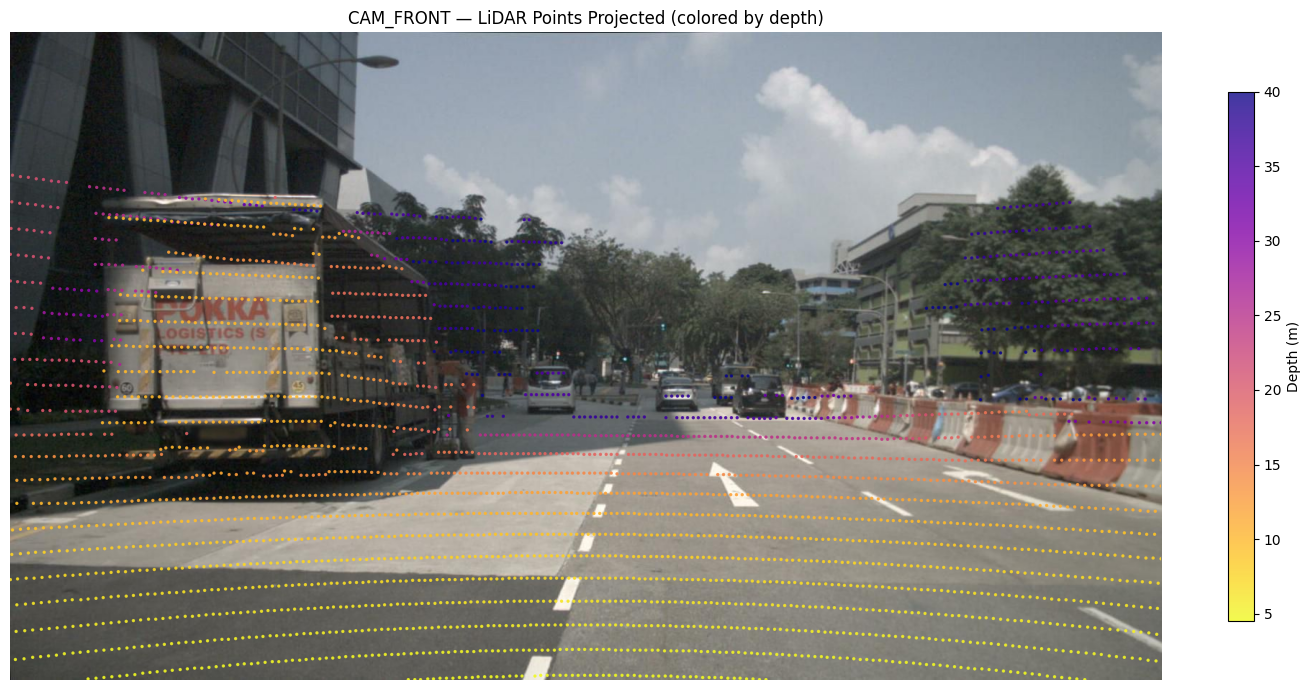

In [16]:
from nuscenes.utils.data_classes import LidarPointCloud
from nuscenes.utils.geometry_utils import view_points

def project_lidar_to_camera(nusc, sample, camera='CAM_FRONT', max_depth=50.0):
    """Project LiDAR points into a camera image, colored by depth."""
    # ── Load LiDAR ───────────────────────────────────────────────
    lidar_token = sample['data']['LIDAR_TOP']
    lidar_sd    = nusc.get('sample_data', lidar_token)
    lidar_cs    = nusc.get('calibrated_sensor', lidar_sd['calibrated_sensor_token'])
    lidar_pose  = nusc.get('ego_pose', lidar_sd['ego_pose_token'])

    pc = LidarPointCloud.from_file(str(DATA_ROOT / lidar_sd['filename']))

    # ── Load camera ──────────────────────────────────────────────
    cam_token = sample['data'][camera]
    cam_sd    = nusc.get('sample_data', cam_token)
    cam_cs    = nusc.get('calibrated_sensor', cam_sd['calibrated_sensor_token'])
    cam_pose  = nusc.get('ego_pose', cam_sd['ego_pose_token'])

    img = np.array(Image.open(DATA_ROOT / cam_sd['filename']))
    K   = np.array(cam_cs['camera_intrinsic'])

    # ── Transform: LiDAR frame -> ego frame -> camera frame ──────
    # 1. LiDAR sensor frame -> ego frame
    pc.rotate(Quaternion(lidar_cs['rotation']).rotation_matrix)
    pc.translate(np.array(lidar_cs['translation']))

    # 2. Ego frame (at LiDAR time) -> global frame
    pc.rotate(Quaternion(lidar_pose['rotation']).rotation_matrix)
    pc.translate(np.array(lidar_pose['translation']))

    # 3. Global frame -> ego frame (at camera time)
    pc.translate(-np.array(cam_pose['translation']))
    pc.rotate(Quaternion(cam_pose['rotation']).rotation_matrix.T)

    # 4. Ego frame -> camera sensor frame
    pc.translate(-np.array(cam_cs['translation']))
    pc.rotate(Quaternion(cam_cs['rotation']).rotation_matrix.T)

    # ── Keep only points in front of camera ─────────────────────
    pts = pc.points[:3, :]  # 3×N
    depths = pts[2, :]
    mask = (depths > 0.1) & (depths < max_depth)
    pts   = pts[:, mask]
    depths = depths[mask]

    # ── Project to image plane ───────────────────────────────────
    proj = view_points(pts, K, normalize=True)  # 3×N
    u = proj[0, :].astype(int)
    v = proj[1, :].astype(int)

    H, W = img.shape[:2]
    in_frame = (u >= 0) & (u < W) & (v >= 0) & (v < H)
    u, v, depths = u[in_frame], v[in_frame], depths[in_frame]

    return img, u, v, depths


img, u, v, depths = project_lidar_to_camera(nusc, sample, 'CAM_FRONT')

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(img)
sc = ax.scatter(u, v, c=depths, cmap='plasma_r', s=2, alpha=0.8,
                vmin=depths.min(), vmax=min(depths.max(), 40))
plt.colorbar(sc, ax=ax, label='Depth (m)', fraction=0.02)
ax.set_title('CAM_FRONT — LiDAR Points Projected (colored by depth)')
ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Annotation Deep Dive — Inspect 3D Box Fields

These fields feed directly into Phase 2 (detection targets) and Phase 5 (BEV projection).

In [17]:
print("Sample annotation fields explained:\n")
ann = nusc.get('sample_annotation', sample['anns'][0])

field_docs = {
    'token':              'Unique ID for this annotation',
    'sample_token':       'Which sample (timestep) this belongs to',
    'instance_token':     'Which object instance (tracks across frames)',
    'visibility_token':   '1-4: percentage of object visible (1=<40%, 4=>80%)',
    'attribute_tokens':   'Object state attributes (moving, stopped, etc.)',
    'translation':        '3D center [x, y, z] in global frame (meters)',
    'size':               '[width, length, height] in meters',
    'rotation':           'Quaternion [w, x, y, z] — heading in global frame',
    'prev':               'Token of same instance in previous sample',
    'next':               'Token of same instance in next sample',
    'num_lidar_pts':      '# LiDAR points inside this box',
    'num_radar_pts':      '# RADAR points inside this box',
    'category_name':      'Full category string (e.g. vehicle.car)',
}

for k, v in ann.items():
    doc = field_docs.get(k, '')
    print(f"  {k:<22} = {str(v):<45}  # {doc}")

Sample annotation fields explained:

  token                  = ef63a697930c4b20a6b9791f423351da               # Unique ID for this annotation
  sample_token           = ca9a282c9e77460f8360f564131a8af5               # Which sample (timestep) this belongs to
  instance_token         = 6dd2cbf4c24b4caeb625035869bca7b5               # Which object instance (tracks across frames)
  visibility_token       = 1                                              # 1-4: percentage of object visible (1=<40%, 4=>80%)
  attribute_tokens       = ['4d8821270b4a47e3a8a300cbec48188e']           # Object state attributes (moving, stopped, etc.)
  translation            = [373.256, 1130.419, 0.8]                       # 3D center [x, y, z] in global frame (meters)
  size                   = [0.621, 0.669, 1.642]                          # [width, length, height] in meters
  rotation               = [0.9831098797903927, 0.0, 0.0, -0.18301629506281616]  # Quaternion [w, x, y, z] — heading in global frame
  pre

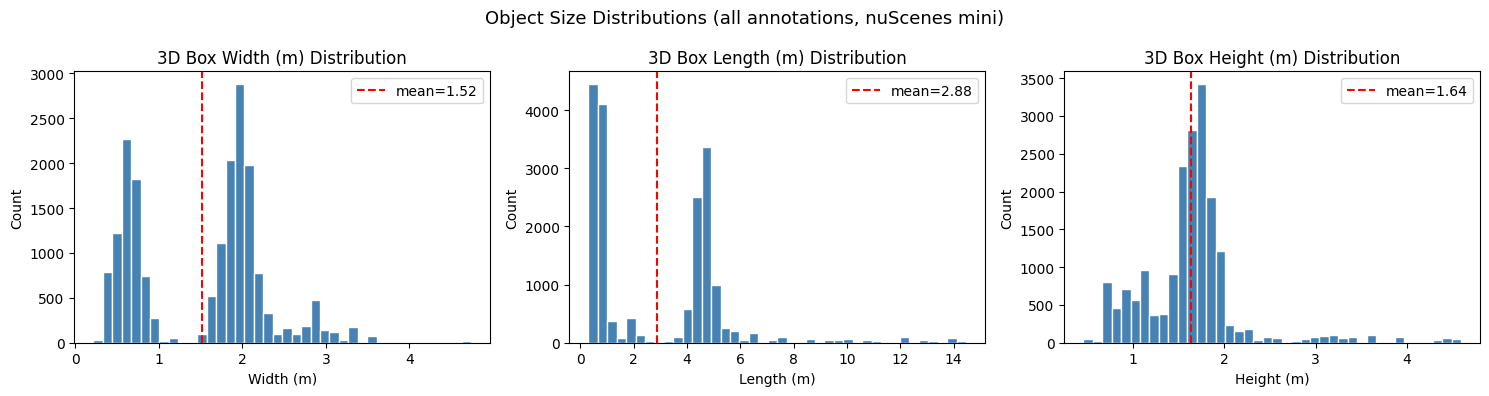

In [18]:
# ── Object size distribution (useful for anchor design in Phase 2) ──
sizes = np.array([[a['size'][0], a['size'][1], a['size'][2]]
                  for a in nusc.sample_annotation])  # N×3 [W, L, H]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['Width (m)', 'Length (m)', 'Height (m)']
for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.hist(sizes[:, i], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(f'3D Box {label} Distribution')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.axvline(sizes[:, i].mean(), color='red', linestyle='--',
               label=f'mean={sizes[:,i].mean():.2f}')
    ax.legend()

plt.suptitle('Object Size Distributions (all annotations, nuScenes mini)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Temporal Continuity — Instance Tracking Across Frames

nuScenes links annotations across time via `prev`/`next` tokens. This is the ground truth for Phase 6 temporal fusion.

In [19]:
# ── Track one vehicle through all frames of scene 0 ─────────────
scene      = nusc.scene[0]
sample_tok = scene['first_sample_token']

# Collect all sample tokens in this scene (ordered)
scene_samples = []
while sample_tok != '':
    s = nusc.get('sample', sample_tok)
    scene_samples.append(s)
    sample_tok = s['next']

print(f"Scene '{scene['name']}' has {len(scene_samples)} ordered samples")

# Find an instance that appears in most frames
instance_frame_count = Counter()
for s in scene_samples:
    for ann_tok in s['anns']:
        ann = nusc.get('sample_annotation', ann_tok)
        instance_frame_count[ann['instance_token']] += 1

top_instance_token, frame_count = instance_frame_count.most_common(1)[0]
top_instance = nusc.get('instance', top_instance_token)
print(f"\nMost tracked instance:")
print(f"  category: {nusc.get('category', top_instance['category_token'])['name']}")
print(f"  appears in {frame_count} / {len(scene_samples)} frames")

Scene 'scene-0061' has 39 ordered samples

Most tracked instance:
  category: human.pedestrian.adult
  appears in 39 / 39 frames


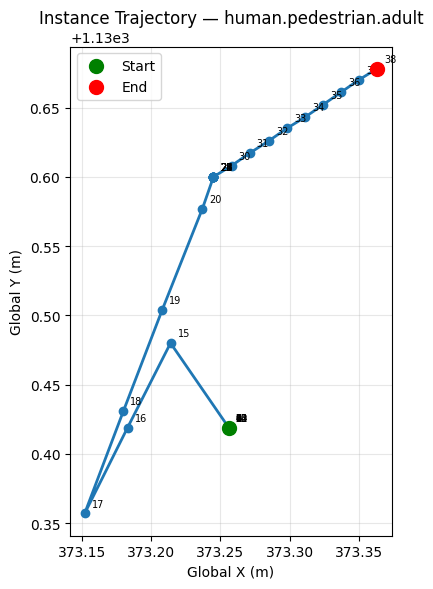

In [20]:
# ── Plot the instance's 3D trajectory (XY in global frame) ───────
positions = []
for s in scene_samples:
    for ann_tok in s['anns']:
        ann = nusc.get('sample_annotation', ann_tok)
        if ann['instance_token'] == top_instance_token:
            positions.append(ann['translation'][:2])  # [x, y]

positions = np.array(positions)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(positions[:, 0], positions[:, 1], 'o-', markersize=6, linewidth=2)
ax.scatter(positions[0, 0], positions[0, 1], s=100, color='green', zorder=5, label='Start')
ax.scatter(positions[-1, 0], positions[-1, 1], s=100, color='red', zorder=5, label='End')
for i, p in enumerate(positions):
    ax.annotate(str(i), p, textcoords='offset points', xytext=(5, 5), fontsize=7)
ax.set_title(f"Instance Trajectory — {nusc.get('category', top_instance['category_token'])['name']}")
ax.set_xlabel('Global X (m)')
ax.set_ylabel('Global Y (m)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()